# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name_: Castaneda, Joaquin
- _Student No._: 2024-09743
- _Section_: THR-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

![MAE_vs_h](MAE_vs_h.png)

**Figure 1.** Mean absolute error versus step size for the forward, backward, and central difference methods for approximating the first derivative.

#### Discussion

The results show that forward and backward differences give us nearly the same approximations, with mean absolute errors around 0.501 and 0.499, respectively. As the spacing between points gets smaller, the forward and backward errors decrease at roughly the same rate as the spacing (which gives a slope of about 1 on the log-log plot). Whereas, central difference, produces a smaller error of only 0.014, which is roughly 35 times smaller, and follows a second-order trend wherein the error decreases with h² (where slope ≈ 2).

This difference occurs because forward and backward formulas use points on only one side, so as a result, they leave a first-order error term. Central difference uses points on both sides of the point, which causes the leading O(h) error terms to cancel and leaves us an O(h²) truncation error.

Forward or backward differentiation is useful at domain boundaries where data on only one side is available. However, for interior points, central difference is preferrable because it provides greater accuracy without greatly increasing the computational cost.


#### Self Reflection

This activity showed me that there are many ways to approximate derivatives even if I am only given discrete data points. Although forward, backward, and central differences all use changes between points to approximate the derivative, their accuracy can be a bit different from each other depending on which points are used.

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

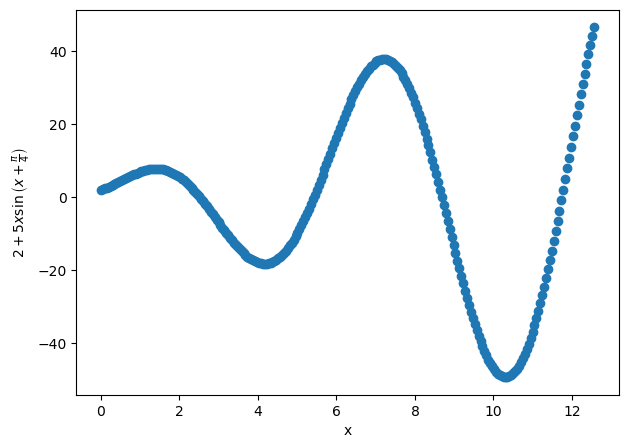

In [45]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)
x = np.linspace(0, 4*np.pi, 257)
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

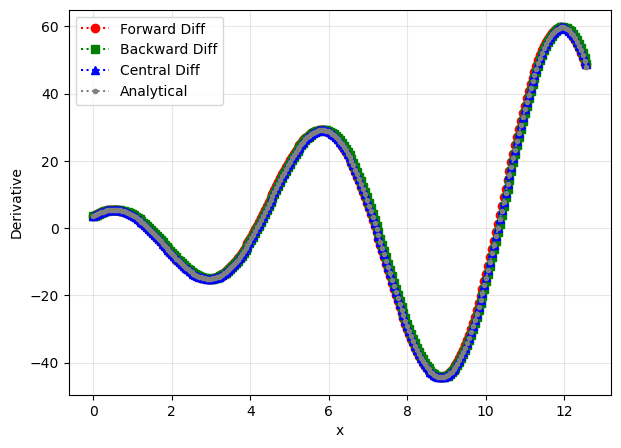

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# From earlier
# f_0 = lambda x: 2 + 5*x*np.sin(x + np.pi/4)
# x = np.linspace(0, 4*np.pi, 257)

def forward(x, f_values):
    dydx = [0.0] * len(x)   # so we have [0, 0, 0, ... 0] 257 zeros
    for i in range(len(x) - 1):   # Forward difference for each point
        h = x[i+1] - x[i]
        dydx[i] = (f_values[i+1] - f_values[i]) / h
    
    # loop doesn't reach last point so we do it
    dydx[-1] = (f_values[-1] - f_values[-2]) / (x[-1] - x[-2])
    
    return dydx

# Do the same idea for backward and central

def backward(x, f_values):
    dydx = [0.0] * len(x)   
    for i in range(1, len(x)):   # Backward difference for each point
        h = x[i] - x[i-1]
        dydx[i] = (f_values[i] - f_values[i-1]) / h
    
    dydx[0] = (f_values[1] - f_values[0]) / (x[1] - x[0])
    
    return dydx


def central(x, f_values):
    dydx = [0.0] * len(x)  
    for i in range(1, len(x) - 1):   # Central difference for interior points
        h = x[i+1] - x[i-1]
        dydx[i] = (f_values[i+1] - f_values[i-1]) / h
    
    # loop doesn't reach first point so we do it
    dydx[0] = (f_values[1] - f_values[0]) / (x[1] - x[0])
    
    dydx[-1] = (f_values[-1] - f_values[-2]) / (x[-1] - x[-2])
    
    return dydx


# Analytical derivative
def f_prime_true(x):
    return 5 * np.sin(x + np.pi/4) + 5 * x * np.cos(x + np.pi/4)


# Compute derivatives
y_values = f_0(x)  # have y values
fd = forward(x, y_values)
bd = backward(x, y_values)
cd = central(x, y_values)

# Compute analytical derivative
yp_true = f_prime_true(x)


# Plotting
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(x, fd, 'r:', marker='o', label='Forward Diff')
ax.plot(x, bd, 'g:', marker='s', label='Backward Diff')
ax.plot(x, cd, 'b:', marker='^', label='Central Diff')
ax.plot(x, yp_true, color='grey', linestyle=':', marker='.', label='Analytical')

ax.set_ylabel("Derivative")
ax.set_xlabel("x")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [29]:
def f_prime_true(x):    # Analytical derivative
    return 5 * np.sin(x + np.pi/4) + 5 * x * np.cos(x + np.pi/4)

yp_true = f_prime_true(x)

In [30]:
# Mean Absolute Error

mae_fd = np.mean(np.abs(fd - yp_true))
mae_bd = np.mean(np.abs(bd - yp_true))
mae_cd = np.mean(np.abs(cd - yp_true))

print(f"Forward MAE:  {mae_fd:.8f}")
print(f"Backward MAE: {mae_bd:.8f}")
print(f"Central MAE:  {mae_cd:.8f}")

Forward MAE:  0.50109164
Backward MAE: 0.49924265
Central MAE:  0.01371666


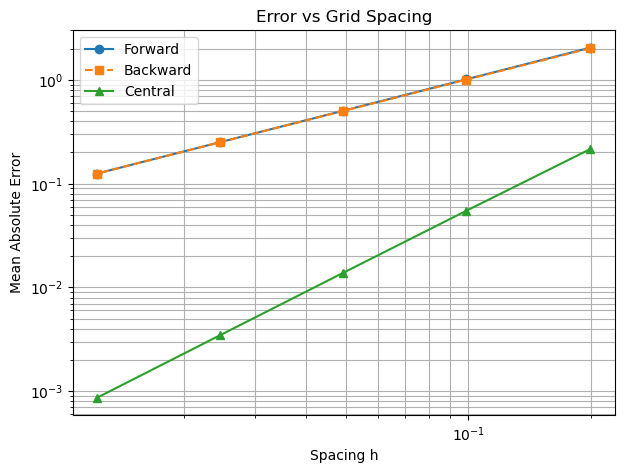

In [55]:
N_list = [64, 128, 256, 512, 1024]   # Different numbers of points
h_list = []
err_fd_list = []
err_bd_list = []
err_cd_list = []

# Calculate the derivative approximations for different numbers of points
for N in N_list:
    x = np.linspace(0, 4*np.pi, N)
    h = x[1] - x[0]
    y = f_0(x)
    yp_true = f_prime_true(x)
    
    fd = forward(x, y)
    bd = backward(x, y)
    cd = central(x, y)

    # Mean Absolute Error
    mae_fd = np.mean(np.abs(fd - yp_true))
    mae_bd = np.mean(np.abs(bd - yp_true))
    mae_cd = np.mean(np.abs(cd - yp_true))

    # Put in empty lists
    h_list.append(h)
    err_fd_list.append(mae_fd)
    err_bd_list.append(mae_bd)
    err_cd_list.append(mae_cd)

# Plotting

plt.figure(figsize=(7,5))

plt.loglog(h_list, err_fd_list, 'o-', label='Forward')
plt.loglog(h_list, err_bd_list, 's--', label='Backward')
plt.loglog(h_list, err_cd_list, '^-', label='Central')

plt.xlabel('Spacing h')
plt.ylabel('Mean Absolute Error')
plt.title('Error vs Grid Spacing')
plt.legend()
plt.grid(True, which='both')
plt.savefig('MAE_vs_h.png', dpi=300, bbox_inches='tight')
plt.show()

#### Problem 1 code summary

This script finds the derivative of a function using forward, backward, and central difference methods and compares them with the analytical derivative using mean absolute error. I used different numbers of points and recorded the spacing and errors to see how the accuracy of each method changes as the spacing gets smaller.

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [12]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]


**End of Notebook.**